In [2]:
# Import libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
# --
list_params = ['outTempMax', 'outTempMin', 'avg_windSpeed', 'total_rain', 'dateTime']

# --
df_mcp = pd.read_csv('data_updt/data_meteo_mcp_2026.csv')[list_params]
df_mcp['dateTime'] = pd.to_datetime(df_mcp['dateTime'])
df_eda = pd.read_csv('data_updt/data_meteo_eda_2026.csv')[list_params]
df_eda['dateTime'] = pd.to_datetime(df_eda['dateTime'])


In [4]:
def rem_outl_std(x, times=2):
    x_median = np.nanmedian(x)
    x_std = np.nanstd(x)
    
    return np.where(((x < x_median-times*x_std) | (x > x_median+times*x_std)), np.nan, x)

def rem_outl_perc(x, lower=1, upper=99):
    x_lower = np.nanpercentile(x, lower)
    x_upper = np.nanpercentile(x, upper)
    return np.where(((x < x_lower) | (x > x_upper)), np.nan, x)

def nanmedian_two(array_1, array_2):
    """Median of two arrays combined, ignoring NaNs.

    The arrays can have different shapes; both are flattened and joined.
    Returns NaN if every value is NaN.
    """
    stack = np.stack([array_1, array_2], axis=0)
    print(stack.shape)
    return np.nanmedian(stack, axis=0)

## Temperature data

### --

In [5]:
# --
df_mcp['TMedn'] = nanmedian_two(rem_outl_std(np.array(df_mcp['outTempMax'])), 
              rem_outl_std(np.array(df_mcp['outTempMin'])))+273

df_eda['TMedn'] = nanmedian_two(rem_outl_std(np.array(df_eda['outTempMax'])), 
              rem_outl_std(np.array(df_eda['outTempMin'])))+273

(2, 1971)
(2, 1562)


/tmp/ipykernel_9722/3849119879.py:20: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(stack, axis=0)


### Explore ERA5 data

In [6]:
# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# --
ds_tp = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-2m-temperatureomkgyya2.nc')

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

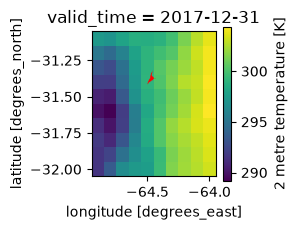

In [117]:
# --
fig, ax = plt.subplots(figsize=(2, 2))
ds_tp.isel(valid_time=0).t2m.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [7]:
# --
ds_tp = ds_tp.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_tp = ds_tp.rio.write_crs("EPSG:4326", inplace=False)

# --
ds_tp_clip = ds_tp.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

### Fill gap with era5

In [8]:
# --
df_t_join = df_mcp[['dateTime', 'TMedn']].merge(df_eda[['dateTime', 'TMedn']], on='dateTime', how="left") 
df_t_join['meanT'] = df_t_join[['TMedn_x', 'TMedn_y']].mean(axis=1)
df_t_join['yy-mm-dd'] = np.array(df_t_join['dateTime']).astype('datetime64[D]')
df_t_join = df_t_join.drop(columns=['dateTime'])

# --
tera5 = ds_tp_clip.median(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
tera5 = tera5.sel(valid_time=slice('2020-01-01', '2026-01-01'))
#df_t_era5 = pd.DataFrame({'yy-mm-dd': })

'''tera5 = ds_tp_clip.median(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
tera5 = tera5.sel(valid_time=slice('2023-01-01', '2026-01-01'))'''
df_t_era = pd.DataFrame({'yy-mm-dd': tera5.valid_time.values.astype('datetime64[D]'),
                         'eraT': tera5.t2m.values})

df_t_era_join = df_t_era.merge(df_t_join, on='yy-mm-dd', how="left") 

/tmp/ipykernel_9722/294114640.py:4: UserWarning: no explicit representation of timezones available for np.datetime64
  df_t_join['yy-mm-dd'] = np.array(df_t_join['dateTime']).astype('datetime64[D]')


<Axes: xlabel='yy-mm-dd'>

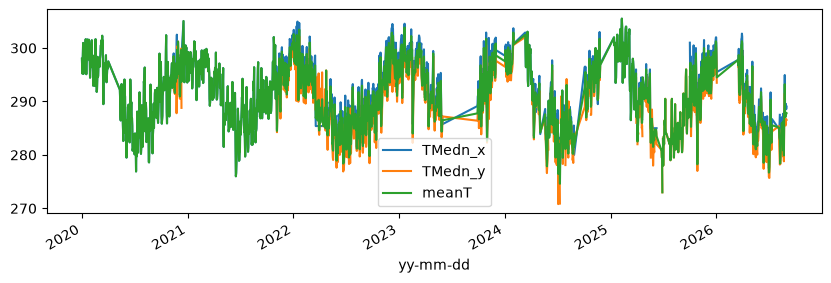

In [9]:
# --
df_t_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [12]:
# --
tera5_mknan = df_t_era_join['eraT'][~np.isnan(df_t_era_join['meanT'])]
tjoin_mknan = df_t_era_join['meanT'][~np.isnan(df_t_era_join['meanT'])]

# --
r, p = pearsonr(tera5_mknan, tjoin_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.957, p = 0.0000


In [13]:
# --
X = np.array(tera5_mknan).reshape(-1, 1)
y = np.array(tjoin_mknan).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

#print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")

R² = 0.927


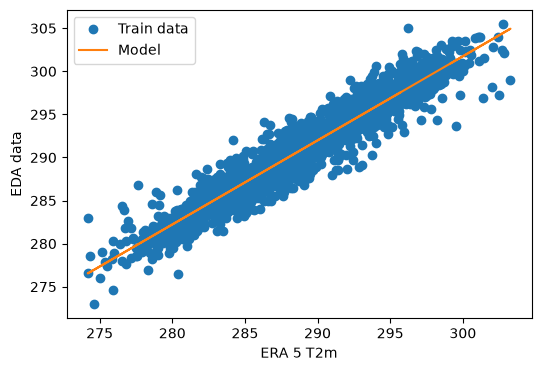

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(X, tjoin_mknan, marker='o', linestyle='none', label='Train data')
ax.plot(X, model.predict(X.reshape(-1, 1)).reshape(-1), label='Model')

# --
ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

In [14]:
# --
mask = df_t_era_join['meanT'].isna()
preds = model.predict(df_t_era_join.loc[mask, 'eraT'].to_numpy().reshape(-1, 1))
df_t_era_join.loc[mask, 'meanT'] = preds

<Axes: xlabel='yy-mm-dd'>

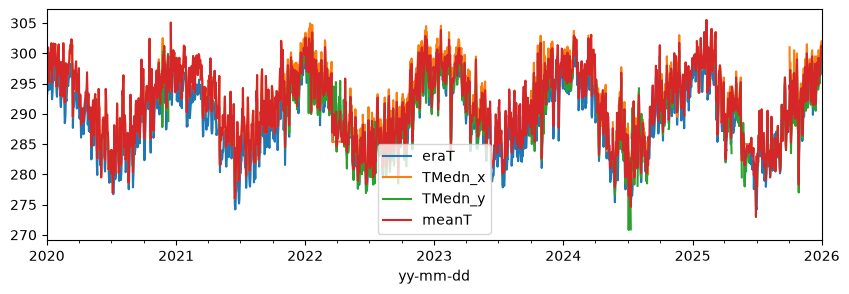

In [15]:
# --
df_t_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

###  Summary

In [16]:
# --
time_values_norm_2326 = df_t_era_join['yy-mm-dd']
tp_values_era5_2326 = df_t_era_join['eraT']
tp_values_eda_2326 = df_t_era_join['meanT']

# --
print(time_values_norm_2326.shape, tp_values_era5_2326.shape, tp_values_eda_2326.shape)

(2193,) (2193,) (2193,)


## Precipitation data

**--**

In [19]:
# --
df_eda['total_rain'] = rem_outl_std(np.array(df_eda['total_rain']))
df_mcp['total_rain'] = rem_outl_std(np.array(df_mcp['total_rain']))

# --
df_p_join = df_mcp[['dateTime', 'total_rain']].merge(df_eda[['dateTime', 'total_rain']], on='dateTime', how="left")
df_p_join['meanp'] = df_p_join[['total_rain_x', 'total_rain_y']].mean(axis=1)
df_p_join['yy-mm-dd'] = np.array(df_p_join['dateTime']).astype('datetime64[D]')
df_p_join = df_p_join.drop(columns=['dateTime'])

/tmp/ipykernel_9722/2958015562.py:8: UserWarning: no explicit representation of timezones available for np.datetime64
  df_p_join['yy-mm-dd'] = np.array(df_p_join['dateTime']).astype('datetime64[D]')


<Axes: xlabel='yy-mm-dd'>

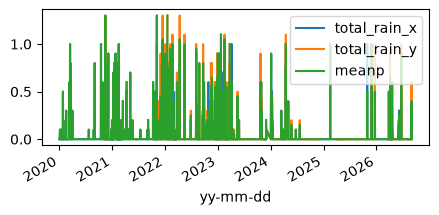

In [20]:
df_p_join.plot(x='yy-mm-dd', figsize=(5, 2))

### Explore ERA5 data

In [21]:
# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# --
ds_tp = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-pressure-precipitationmqdk43fk.nc')

<Axes: title={'center': 'valid_time = 2018-01-08T08:00:00'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

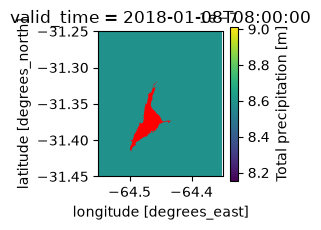

In [130]:
# --
fig, ax = plt.subplots(figsize=(2, 2))

# --
ds_tp.isel(valid_time=200).sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).tp.plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [22]:
# --
ds_tp = ds_tp.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
ds_tp = ds_tp.rio.write_crs("EPSG:4326", inplace=False)

# --
ds_tp_clip = ds_tp.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

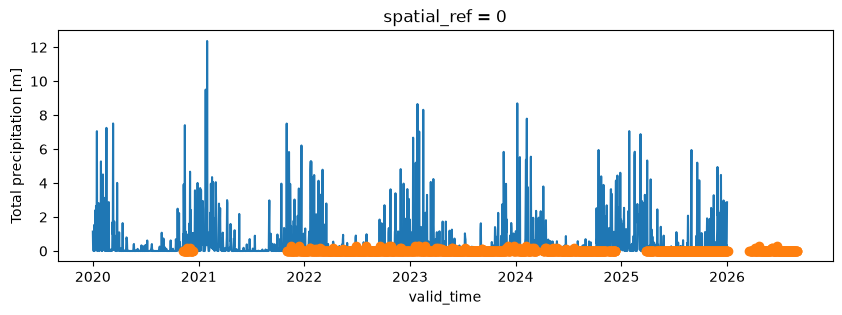

In [23]:
fig, ax = plt.subplots(figsize=(10, 3))

# --
tp_spatial_medn = ds_tp_clip.sel(longitude=slice(-64.6, -64.4), latitude=slice(-31.4, -31.2)).median(dim=['latitude', 'longitude'])
tp_spatial_medn = tp_spatial_medn.sel(valid_time=slice('2020-01-01', '2026-01-01'))
'''
Accumulated liquid and frozen water, including rain and snow, that falls to the Earth's surface. It is the sum of large-scale precipitation 
(that precipitation which is generated by large-scale weather patterns, such as troughs and cold fronts) and convective precipitation (generated 
by convection which occurs when air at lower levels in the atmosphere is warmer and less dense than the air above, so it rises). Precipitation 
variables do not include fog, dew or the precipitation that evaporates in the atmosphere before it lands at the surface of the Earth. 
This variable is accumulated from the beginning of the forecast time to the end of the forecast step. The units of precipitation are depth 
in metres. It is the depth the water would have if it were spread evenly over the grid box. Care should be taken when comparing model 
variables with observations, because observations are often local to a particular point in space and time, rather than representing averages 
over a model grid box and model time step.

Measurement at 00:00:00 is the accumulated for the day before
'''

tp_spatial_medn_res = tp_spatial_medn.resample(valid_time="1D").max() * 1000
tp_total_daily = np.concatenate((tp_spatial_medn_res.tp.values[1:], np.array([0])))

# --
tp_spatial_medn_res.tp.plot(ax=ax)
ax.plot(df_eda['dateTime'], rem_outl_std(np.array(df_eda['total_rain'])), marker='o', linestyle='none', label='')


### Fill gaps

In [24]:
# --
pera5 = tp_total_daily

df_p_era = pd.DataFrame({'yy-mm-dd': tp_spatial_medn_res.valid_time.values.astype('datetime64[D]'),
                         'eraP': pera5})

df_p_era_join = df_p_era.merge(df_p_join, on='yy-mm-dd', how="left") 

<Axes: xlabel='yy-mm-dd'>

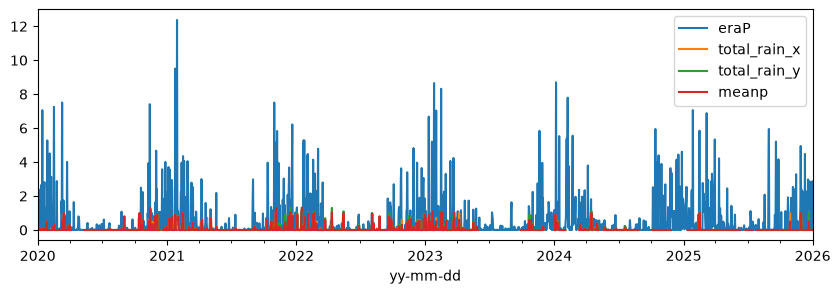

In [25]:
# --
df_p_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [26]:
# --
pera5_mknan = df_p_era_join['eraP'][~np.isnan(df_p_era_join['meanp'])]
pjoin_mknan = df_p_era_join['meanp'][~np.isnan(df_p_era_join['meanp'])]

df_p_era_join

# --
r, p = pearsonr(pera5_mknan, pjoin_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.145, p = 0.0000


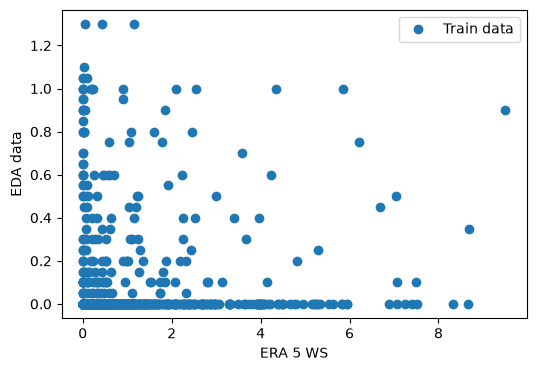

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(pera5_mknan, pjoin_mknan, marker='o', linestyle='none', label='Train data')

# --
ax.set_xlabel('ERA 5 WS')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

Conclusión: Por $R^{2}$ bajo, no se llena el gap con ERA5

### Summary

In [28]:
# --
time_values_norm_2326 = df_p_era_join['yy-mm-dd']
p_values_era5_2326 = np.array(df_p_era_join['eraP'])

# --
print(time_values_norm_2326.shape, p_values_era5_2326.shape)

(2193,) (2193,)


## Wind data

**--**

In [30]:
# --
df_w_join = df_mcp[['dateTime', 'avg_windSpeed']].merge(df_eda[['dateTime', 'avg_windSpeed']], on='dateTime', how="left")
df_w_join['avg_windSpeed_x'] = df_w_join['avg_windSpeed_x'] * 0.277778
df_w_join['avg_windSpeed_y'] = df_w_join['avg_windSpeed_y'] * 0.277778

In [31]:
# --
df_w_join['meanW'] = df_w_join[['avg_windSpeed_x', 'avg_windSpeed_y']].mean(axis=1)

df_w_join['yy-mm-dd'] = np.array(df_w_join['dateTime']).astype('datetime64[D]')
df_w_join = df_w_join.drop(columns=['dateTime'])

/tmp/ipykernel_9722/3010943536.py:4: UserWarning: no explicit representation of timezones available for np.datetime64
  df_w_join['yy-mm-dd'] = np.array(df_w_join['dateTime']).astype('datetime64[D]')


<Axes: xlabel='yy-mm-dd'>

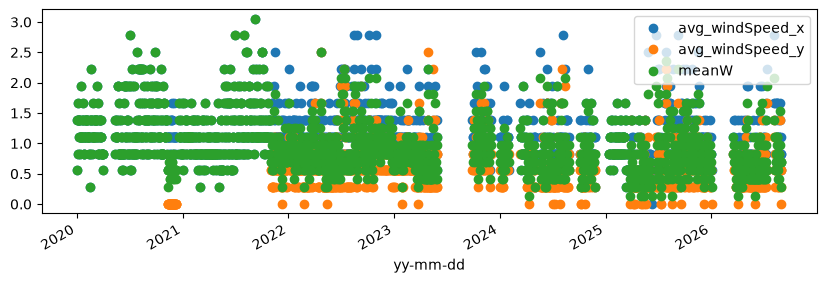

In [32]:
df_w_join.plot(x='yy-mm-dd', marker='o', linestyle='none', figsize=(10, 3))

**--**

In [33]:
# --
esr_vector = gpd.read_file('https://github.com/francobarrionuevoenv21/MAIE_devs_pub/raw/refs/heads/main/Proc_Img/tp_final_claS2/data/esr_clean.geojson').to_crs('EPSG:4326')

# --
ds_w = xr.open_dataset('data/reanalysis-era5-land-timeseries-sfc-wind529wrpgo.nc')

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

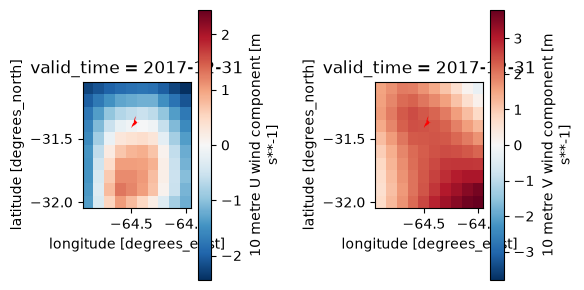

In [151]:
# --
fig, ax = plt.subplots(1, 2, figsize=(6, 3), tight_layout=True)
ax = ax.flatten()

# --
ds_w.isel(valid_time=0).u10.plot(ax=ax[0])
esr_vector.dissolve().plot(ax=ax[0], color='red')

# --
ds_w.isel(valid_time=0).v10.plot(ax=ax[1])
esr_vector.dissolve().plot(ax=ax[1], color='red')

In [34]:
# --
vel_mag = xr.ufuncs.sqrt(ds_w.u10**2+ds_w.v10**2)

<Axes: title={'center': 'valid_time = 2017-12-31'}, xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>

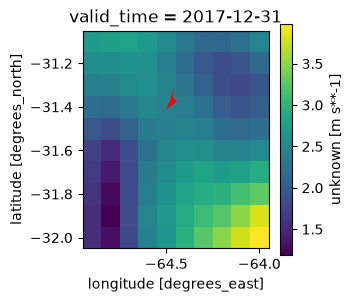

In [152]:
# --
fig, ax = plt.subplots(figsize=(3, 3))

# --
vel_mag.isel(valid_time=0).plot(ax=ax)
esr_vector.dissolve().plot(ax=ax, color='red')

In [35]:
# --
da_w = vel_mag.rio.set_spatial_dims(x_dim='longitude', y_dim='latitude', inplace=False)
da_w = da_w.rio.write_crs("EPSG:4326", inplace=False)

# --
da_w_clip = da_w.rio.clip(esr_vector.geometry, all_touched=True)

/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=0, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=1, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/features.py:381: ShapeSkipWarning: Invalid shape will not be rasterized: geometry={'type': 'MultiPolygon', 'coordinates': []}, index=2, value=1, error=ValueError('Input is not a valid geometry object')
  _rasterize(
/home/franco-barrionuevo/miniconda3/envs/sar_maie/lib/python3.14/site-packages/rasterio/

**Fill gaps**

In [36]:
# --
wera5 = da_w_clip.median(dim=['latitude', 'longitude']).resample(valid_time='1D').mean()
wera5 = wera5.sel(valid_time=slice('2020-01-01', '2026-01-01'))
#df_t_era5 = pd.DataFrame({'yy-mm-dd': })

df_w_era = pd.DataFrame({'yy-mm-dd': tera5.valid_time.values.astype('datetime64[D]'),
                         'eraW': wera5.values})

df_w_era_join = df_w_era.merge(df_w_join, on='yy-mm-dd', how="left")

<Axes: xlabel='yy-mm-dd'>

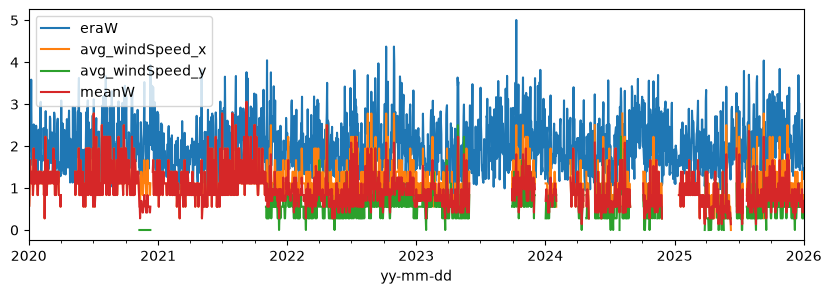

In [37]:
# --
df_w_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [38]:
# --
wera5_mknan = df_w_era_join['eraW'][~np.isnan(df_w_era_join['meanW'])]
wjoin_mknan = df_w_era_join['meanW'][~np.isnan(df_w_era_join['meanW'])]

# --
r, p = pearsonr(wera5_mknan, wjoin_mknan)
print(f"r = {r:.3f}, p = {p:.4f}")

r = 0.593, p = 0.0000


In [39]:
# --
X = np.array(wera5_mknan).reshape(-1, 1)
y = np.array(wjoin_mknan).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

#print(f"MAE = {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R² = {r2_score(y_test, y_pred):.3f}")

R² = 0.305


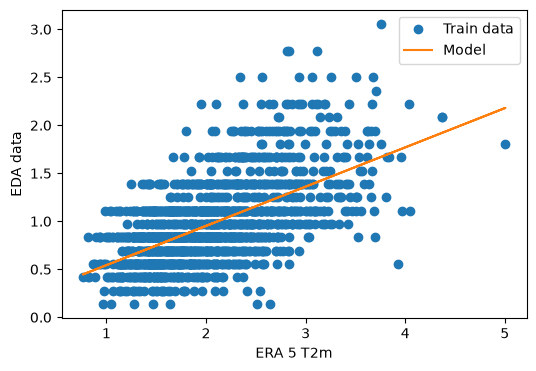

In [40]:
fig, ax = plt.subplots(figsize=(6, 4))

# --
ax.plot(X, wjoin_mknan, marker='o', linestyle='none', label='Train data')
ax.plot(X, model.predict(X.reshape(-1, 1)).reshape(-1), label='Model')

# --
ax.set_xlabel('ERA 5 T2m')
ax.set_ylabel('EDA data')
ax.legend(loc='best')

In [41]:
# --
mask = df_w_era_join['meanW'].isna()
preds = model.predict(df_w_era_join.loc[mask, 'eraW'].to_numpy().reshape(-1, 1))
df_w_era_join.loc[mask, 'meanW'] = preds

<Axes: xlabel='yy-mm-dd'>

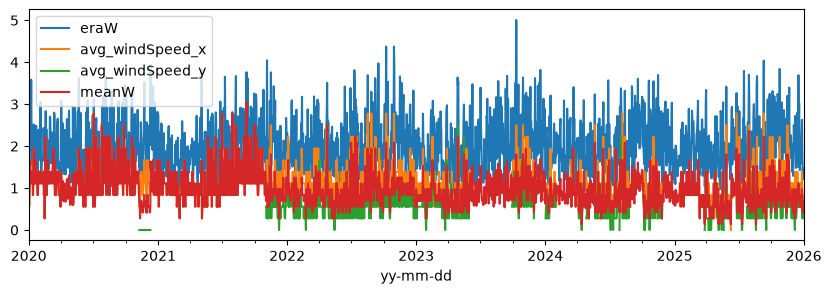

In [42]:
# --
df_w_era_join.plot(x='yy-mm-dd', figsize=(10, 3))

In [43]:
df_w_era_join.head()

,yy-mm-dd,eraW,avg_windSpeed_x,avg_windSpeed_y,meanW
0,2020-01-01,2.063640,1.388890,NaN,1.388890
1,2020-01-02,1.730708,0.555556,NaN,0.555556
2,2020-01-03,1.696078,0.833334,NaN,0.833334
3,2020-01-04,1.747064,1.388890,NaN,1.388890
4,2020-01-05,2.566181,1.666668,NaN,1.666668


### Summary

In [44]:
# --
time_values_norm_2326 = df_w_era_join['yy-mm-dd']
w_values_era5_2326 = df_w_era_join['eraW']
w_values_eda_2326 = df_w_era_join['meanW']

# --
print(time_values_norm_2326.shape, w_values_era5_2326.shape, w_values_eda_2326.shape)

(2193,) (2193,) (2193,)


## Merga all data

In [45]:
# --
df_merged = pd.DataFrame()

# --
df_merged['yy-mm-dd'] = time_values_norm_2326
df_merged['TP-ERA5_K'] = tp_values_era5_2326
df_merged['TP-EDAMCP_K'] = tp_values_eda_2326

# --
df_merged['PP-ERA5_mm'] = p_values_era5_2326

# --
df_merged['WM-ERA5_ms'] = w_values_era5_2326
df_merged['WD-EDAMCP_ms'] = w_values_eda_2326

In [46]:
# --
df_merged.head(10)

,yy-mm-dd,TP-ERA5_K,TP-EDAMCP_K,PP-ERA5_mm,WM-ERA5_ms,WD-EDAMCP_ms
0,2020-01-01,295.672638,298.00,0.046566,2.063640,1.388890
1,2020-01-02,293.127289,295.25,0.016376,1.730708,0.555556
2,2020-01-03,294.136627,297.50,0.001578,1.696078,0.833334
3,2020-01-04,295.408447,298.50,0.000870,1.747064,1.388890
4,2020-01-05,297.788544,300.95,1.537986,2.566181,1.666668
5,2020-01-06,293.906403,295.15,0.000000,2.398733,1.388890
6,2020-01-07,294.418335,297.10,0.103697,2.612349,1.388890
7,2020-01-08,296.774445,300.00,0.152364,3.584239,1.388890
8,2020-01-09,296.315216,298.40,2.410516,2.341919,1.111112
9,2020-01-10,294.040161,297.15,0.102237,1.892733,1.111112


In [48]:
# --
df_merged.to_csv('output/meteo_merged_2326V4.csv', index=False)